Missing Values

1 - Raw Data (will have lot of missing values)

Eg - Given Form to fill a survey, some fields can be empty - dataset will get a missing values


3 Mechanisms

MCAR -- Missing Completely at random -- Missing value are randomly missing throughout the dataset and there is no such reason why the value is missing from the dataset
eg -- survey about something, missing questions --- MCAR


MAR -- Missing at random -- Missing data is dependent on the observed data
missing value is systematic related to observed data


MNAR -- Missing Data not at random
Missingness is not random and it is depended on unobserved and unmeasured factors

eg -- Missingness is dependent on job satisfaction




In [2]:
## Examples --
import seaborn as sns

In [3]:
df=sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Check missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Delete the rows or data points to handle missing values (Problem is we will lose data)
df.shape

(891, 15)

In [6]:
df.dropna().shape  # Not Good Idea, losing almost all the data

(182, 15)

In [7]:
df.dropna(axis=1).shape

(891, 11)

# Imputation Missing Values Techniques

- Mean Value Imputation


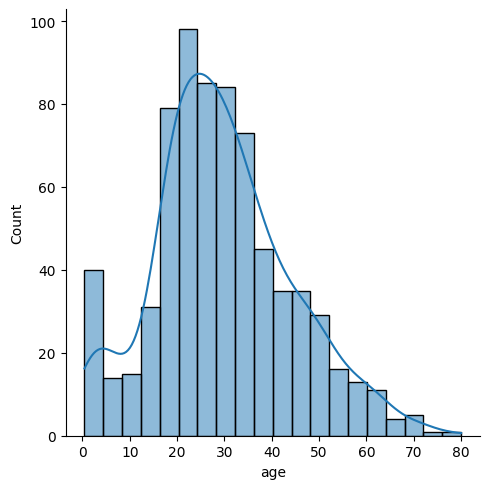

In [8]:
sns.displot(df["age"],kde=True)

In [9]:
df["age_mean"]=df["age"].fillna(df["age"].mean())


In [10]:
df[["age_mean","age"]]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [11]:
# Mean imputation works well when we have a normally distributed data
# What if you have a different distribution (Replace the NaN with median if outliers are there causing left or right skewness)

In [12]:
# Median Imputation (If we have outliers in dataset)

df["age_median"]=df["age"].fillna(df["age"].median())
df[["age_median","age_mean","age"]]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


In [13]:
# Mode Imputation Technique Can be used with categorical values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
 15  age_mean     891 non-null    float64 
 16  age_median   891 non-null    float64 
dtypes: bool(2), category(2), float64(4), int64(4), str(5)
memory usage: 94.6 KB


In [14]:
df[df["embarked"].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [15]:
df["embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [16]:
mode_value=df[df["embarked"].notna()]["embarked"].mode()[0]
mode_value

'S'

In [17]:
df["embarked_mode"]=df["embarked"].fillna(mode_value)

df[["embarked","embarked_mode"]]

,embarked,embarked_mode
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [18]:
df.isnull().sum()

survived           0
pclass             0
sex                0
age              177
sibsp              0
parch              0
fare               0
embarked           2
class              0
who                0
adult_male         0
deck             688
embark_town        2
alive              0
alone              0
age_mean           0
age_median         0
embarked_mode      0
dtype: int64

In [19]:
df.iloc[61]

survived              1
pclass                1
sex              female
age                38.0
sibsp                 0
parch                 0
fare               80.0
embarked            NaN
class             First
who               woman
adult_male        False
deck                  B
embark_town         NaN
alive               yes
alone              True
age_mean           38.0
age_median         38.0
embarked_mode         S
Name: 61, dtype: object

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median,embarked_mode
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0,S
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0,C
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0,S
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0,S
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0,S


In [21]:
df.isnull().sum()

survived           0
pclass             0
sex                0
age              177
sibsp              0
parch              0
fare               0
embarked           2
class              0
who                0
adult_male         0
deck             688
embark_town        2
alive              0
alone              0
age_mean           0
age_median         0
embarked_mode      0
dtype: int64

In [22]:
df["embark_town"].unique()

<StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

In [23]:
import numpy as np
choice=np.random.choice(df[df["embark_town"].notnull()]["embark_town"].unique())

print(choice)

Cherbourg


In [24]:
df["embark_town_random"]=df["embark_town"].fillna(choice)

df["embark_town_random"].isnull().sum()

np.int64(0)

In [25]:
df[["embark_town_random","embarked","embark_town"]]

,embark_town_random,embarked,embark_town
0,Southampton,S,Southampton
1,Cherbourg,C,Cherbourg
2,Southampton,S,Southampton
3,Southampton,S,Southampton
4,Southampton,S,Southampton
...,...,...,...
886,Southampton,S,Southampton
887,Southampton,S,Southampton
888,Southampton,S,Southampton
889,Cherbourg,C,Cherbourg


In [26]:
df[df["embark_town"].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median,embarked_mode,embark_town_random
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0,S,Cherbourg
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0,S,Cherbourg


In [27]:
df.loc[[61,829],["embark_town","embark_town_random"]]

,embark_town,embark_town_random
61,NaN,Cherbourg
829,NaN,Cherbourg


In [28]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median,embarked_mode,embark_town_random
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True,27.000000,27.0,S,Southampton
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True,19.000000,19.0,S,Southampton
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False,29.699118,28.0,S,Southampton
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True,26.000000,26.0,C,Cherbourg
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True,32.000000,32.0,Q,Queenstown


In [45]:
mode_value=df[df["deck"].notnull()]["deck"].mode()[0]

In [46]:
#df["deck"].unique()
print(mode_value)

C


In [47]:
df["deck_mode"]=df["deck"].fillna(mode_value)

In [49]:
df[["deck_mode","deck"]].notnull().sum()

deck_mode    891
deck         203
dtype: int64

In [50]:
df.shape

(891, 20)